<a href="https://colab.research.google.com/github/alizadangi02/Linear-Regression-task/blob/main/LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

What Is Linear Regression?

Linear Regression is a machine learning algorithm that finds a mathematical relationship between input features and output value.

It tries to learn this type of equation:

**Price=b0+b1x1+b2x2+b3x3+...**

Where:

x1, x2, x3 = features (rooms, income, etc.)

b1, b2 = coefficients (importance)

b0 = intercept



# **Simple Linear Regression on Housing Prices**

The dataset (housing.csv) contains:

longitude

latitude

housing_median_age

total_rooms

total_bedrooms

population

households

median_income

ocean_proximity

median_house_value

The goal is to predict:

***median_house_value (house price)***

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("housing.csv")
print(df.head())
print(df.info())
print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639

In [ ]:
print(df.isnull().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [ ]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

In [ ]:
df['total_bedrooms'].isnull().sum()

np.int64(0)

In [ ]:
df = df.drop("ocean_proximity", axis=1)

In [ ]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 5059928371.165357
RMSE: 71133.17349286025
R2 Score: 0.6138664756435176


In [ ]:
coefficients = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
print(coefficients.sort_values(by="Coefficient", ascending=False))

                     Coefficient
median_income       77194.699466
total_bedrooms      48712.343341
households          17654.500659
housing_median_age  14905.906448
total_rooms        -17805.418501
population         -43766.491159
longitude          -85503.218153
latitude           -90698.848803


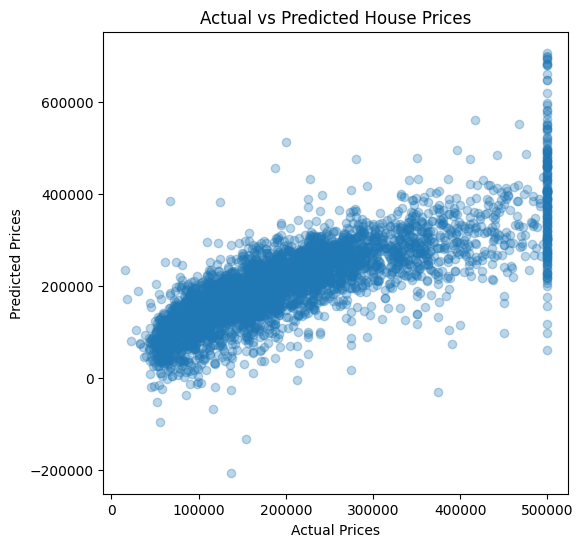

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()